# Stylometry
Find differences between academic and news texts in BNC using a couple metrics

In [1]:
import sys

if ".." not in sys.path:
    sys.path.append("..")

import polars as pl
import polars.selectors as cs
import polars_corpus as plc

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
bnc = pl.read_parquet("bnc.parquet")

In [3]:
m = plc.search(bnc, '[lemma="tweak"]')

In [4]:
# filter for academic prose and news texts, normalize tokens
bnc = bnc.filter(pl.col("text_type").is_in(["ACPROSE", "NEWS"])).with_columns(
    pl.col("token").str.to_lowercase().alias("norm")
)

# remove punctuation and spaces ("</gap>")
bnc = bnc.filter(pl.col("lemma").is_not_null())
bnc

token,lemma,pos,c5,sent_tag,mode,text_type,file_id,speaker_id,norm
str,str,str,str,str,cat,cat,cat,str,str
"""NEEDLES""","""needle""","""SUBST""","""NN2""","""B""","""written""","""ACPROSE""","""A04""",null,"""needles"""
"""IN""","""in""","""PREP""","""PRP""","""I""","""written""","""ACPROSE""","""A04""",null,"""in"""
"""HAY""","""hay""","""SUBST""","""NP0""","""I""","""written""","""ACPROSE""","""A04""",null,"""hay"""
"""IS""","""be""","""VERB""","""VBZ""","""I""","""written""","""ACPROSE""","""A04""",null,"""is"""
"""IT""","""it""","""SUBST""","""NN1""","""I""","""written""","""ACPROSE""","""A04""",null,"""it"""
…,…,…,…,…,…,…,…,…,…
"""and""","""and""","""CONJ""","""CJC""","""I""","""written""","""NEWS""","""K97""",null,"""and"""
"""Dog""","""dog""","""SUBST""","""NN1""","""I""","""written""","""NEWS""","""K97""",null,"""dog"""
"""pub""","""pub""","""SUBST""","""NN1""","""I""","""written""","""NEWS""","""K97""",null,"""pub"""


Mean segmental type-token ratio (MSTTR)

In [5]:
# calculate msttr, some files removed (why?)
msttr = (
    bnc.with_columns(index=pl.int_range(pl.len()))
    .group_by_dynamic("index", every="1000i", group_by="file_id")
    .agg(tokens=pl.col("norm").len(), types=pl.col("norm").n_unique())
    .filter(pl.col("tokens") == 1000)
    .with_columns(msttr=pl.col("types") / pl.col("tokens"))
)
msttr

file_id,index,tokens,types,msttr
cat,i64,u32,u32,f64
"""A04""",0,1000,437,0.437
"""A04""",1000,1000,452,0.452
"""A04""",2000,1000,436,0.436
"""A04""",3000,1000,426,0.426
"""A04""",4000,1000,430,0.43
…,…,…,…,…
"""K97""",25187000,1000,532,0.532
"""K97""",25188000,1000,500,0.5
"""K97""",25189000,1000,512,0.512


In [6]:
# average out msttr for each file
msttr_table = msttr.group_by("file_id").agg(pl.col("msttr").mean()).sort(by="msttr")

In [7]:
# add genre column back in
msttr_table = msttr_table.join(
    bnc.select("file_id", "text_type").unique(), on="file_id", how="left"
)
msttr_table

file_id,msttr,text_type
cat,f64,cat
"""FDF""",0.289,"""ACPROSE"""
"""J71""",0.297375,"""ACPROSE"""
"""FBS""",0.301,"""ACPROSE"""
"""FD0""",0.3078,"""ACPROSE"""
"""FC4""",0.308125,"""ACPROSE"""
…,…,…
"""A5B""",0.558,"""NEWS"""
"""A8L""",0.565,"""NEWS"""
"""A32""",0.57,"""NEWS"""


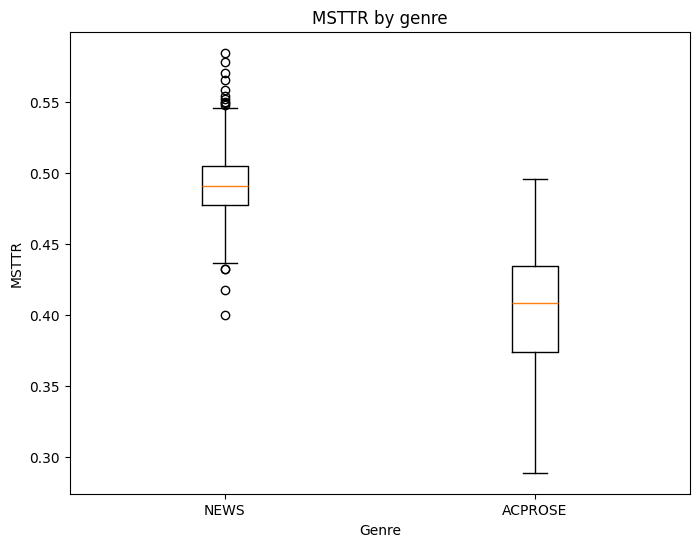

In [8]:
# make a boxplot
categories = msttr_table["text_type"].to_list()
values = msttr_table["msttr"].to_list()

category_data = []

for category in set(categories):
    category_values = [
        values[i] for i in range(len(categories)) if categories[i] == category
    ]
    category_data.append(category_values)

plt.figure(figsize=(8, 6))
plt.boxplot(category_data, tick_labels=set(categories))
plt.xlabel("Genre")
plt.ylabel("MSTTR")
plt.title("MSTTR by genre")
plt.show()

Pointwise mutual information

In [9]:
freq_table = plc.crosstab(bnc, pl.col("norm"), "text_type")
freq_table

norm,text_type,f12,f1,f2,n
str,cat,u32,u32,u32,u32
"""-{gm}""","""ACPROSE""",1,1,15780648,25192822
"""0.5–11""","""ACPROSE""",2,2,15780648,25192822
"""alric""","""ACPROSE""",4,4,15780648,25192822
"""ah/00/23/0006""","""ACPROSE""",1,1,15780648,25192822
"""non-scientist""","""ACPROSE""",2,2,15780648,25192822
…,…,…,…,…,…
"""younis2""","""NEWS""",1,1,9412174,25192822
"""lint-bandage""","""NEWS""",1,1,9412174,25192822
"""b/00/23/2166""","""ACPROSE""",1,1,15780648,25192822


In [10]:
pmi_table = freq_table.with_columns(pmi=plc.pmi("f12", "f1", "f2", "n")).sort(
    by="pmi", descending=True
)
pmi_table

norm,text_type,f12,f1,f2,n,pmi
str,cat,u32,u32,u32,u32,f64
"""experiences""","""NEWS""",152,1369,9412174,25192822,9.260168
"""carrying""","""NEWS""",645,1369,9412174,25192822,9.130753
"""variable""","""NEWS""",35,1369,9412174,25192822,7.791635
"""talking""","""ACPROSE""",599,1361,15780648,25192822,6.733503
"""namely""","""ACPROSE""",1020,1089,15780648,25192822,6.688564
…,…,…,…,…,…,…
"""violent""","""NEWS""",341,835,9412174,25192822,-8.379942
"""donald""","""NEWS""",341,394,9412174,25192822,-8.419602
"""sharply""","""ACPROSE""",341,516,15780648,25192822,-8.456517
